In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
from pathlib import Path
root_path = Path().resolve().parent.parent
sys.path.append(str(root_path))

from utils.eda import summary_stats, missing_report, outlier_report, class_balance, correlation_matrix
from utils.visualization import *

In [2]:
df = pd.read_csv(root_path / "heart failure prediction" / 'data' / 'heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
summary_stats(df)

SHAPE        : 918 rows × 12 columns

── DTYPES ──
                  dtype  nunique  sample
Age               int64       50      40
Sex              object        2       M
ChestPainType    object        4     ATA
RestingBP         int64       67     140
Cholesterol       int64      222     289
FastingBS         int64        2       0
RestingECG       object        3  Normal
MaxHR             int64      119     172
ExerciseAngina   object        2       N
Oldpeak         float64       53     0.0
ST_Slope         object        3      Up
HeartDisease      int64        2       0


In [4]:
missing_report(df)

MISSING VALUE REPORT  (total kolom: 12)
✓ Tidak ada missing values.


In [5]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

Jumlah data duplikat: 0


In [7]:
outlier_report(df)

OUTLIER REPORT  (method=iqr)
     column  n_outliers  pct_outliers  has_outlier  lower_bound  upper_bound
  FastingBS         214         23.31         True        0.000        0.000
Cholesterol         183         19.93         True       32.625      407.625
  RestingBP          28          3.05         True       90.000      170.000
    Oldpeak          16          1.74         True       -2.250        3.750
      MaxHR           2          0.22         True       66.000      210.000

Kolom dengan outlier: 5 / 7


In [8]:
class_balance(df, 'HeartDisease')

CLASS BALANCE — 'HeartDisease'
              count    pct
HeartDisease              
1               508  55.34
0               410  44.66

Imbalance ratio (max/min): 1.24x
✓  Dataset relatif balanced.


In [9]:
fitur_numeric = df.select_dtypes(include='number').columns.tolist()
fitur_category = df.select_dtypes(include=['object']).columns.tolist()

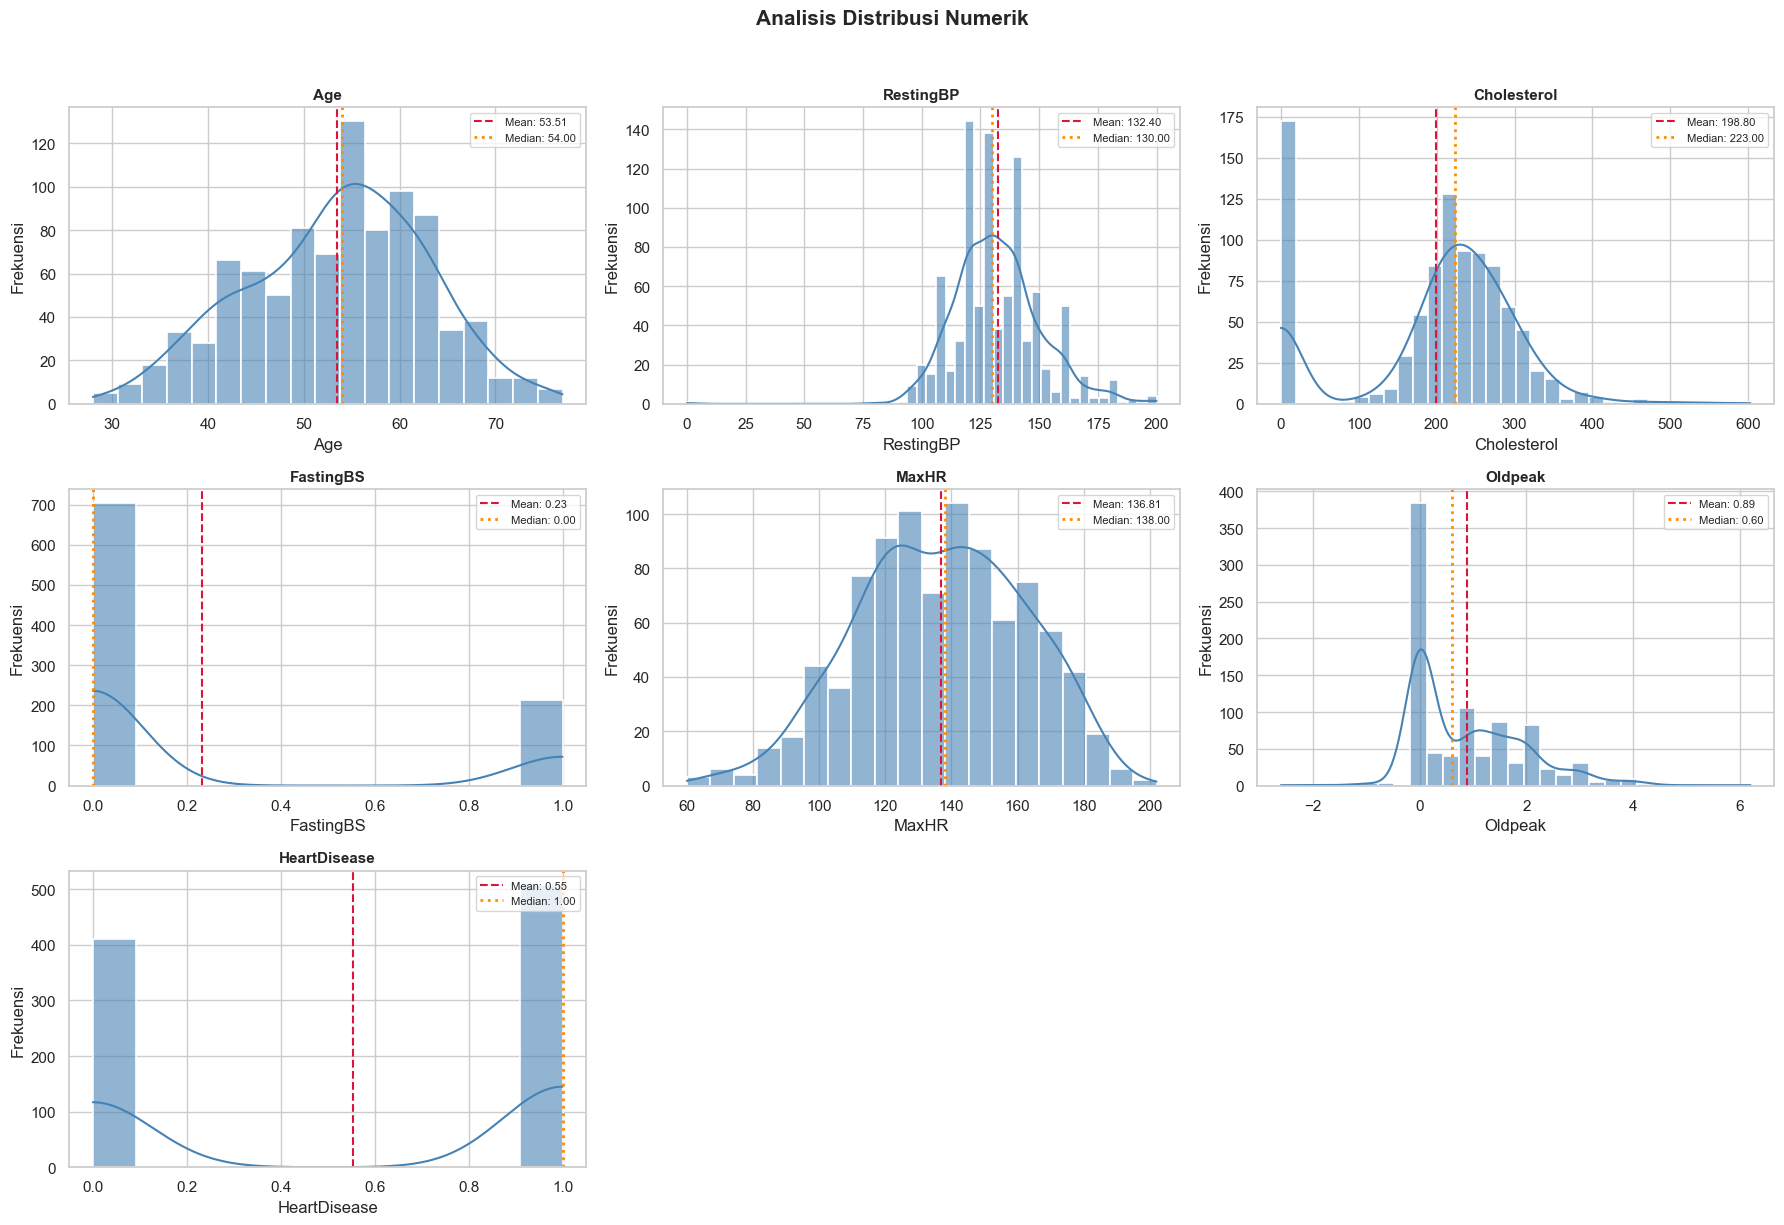

In [10]:
plot_distributions(df, fitur_numeric)

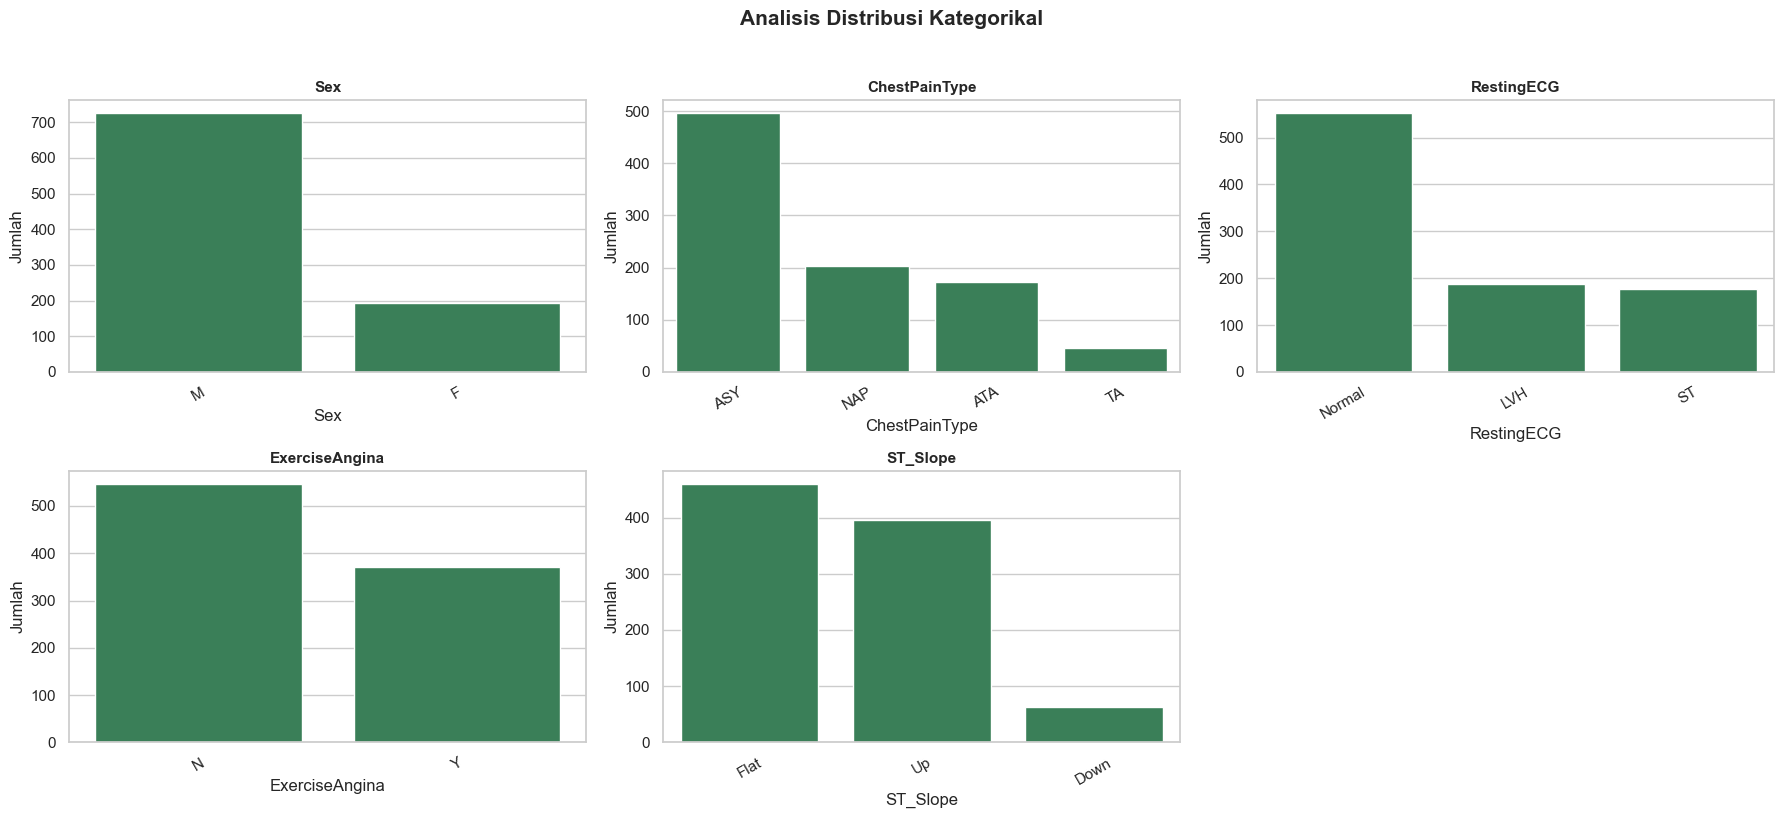

In [11]:
plot_distributions(df, fitur_category)

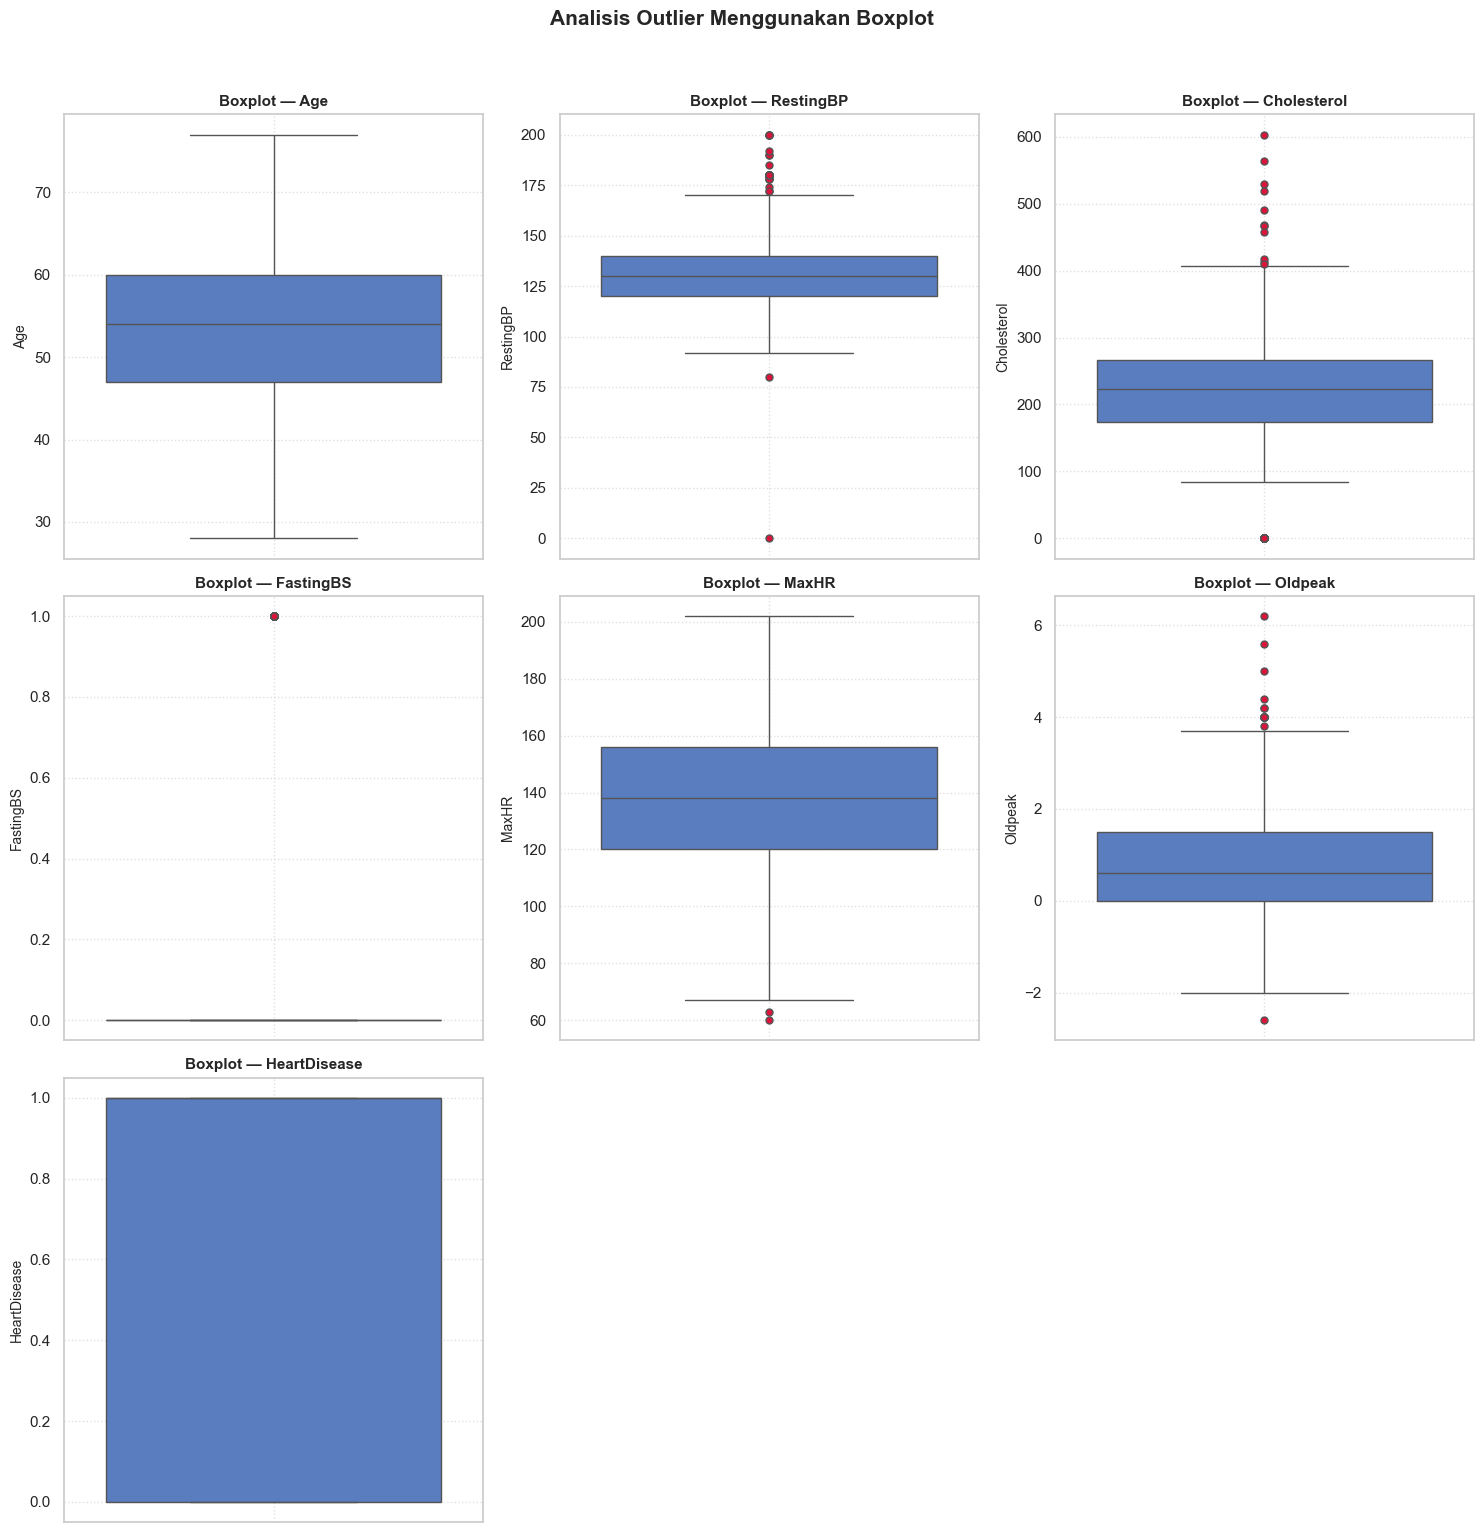

In [12]:
plot_boxplot(df, fitur_numeric)

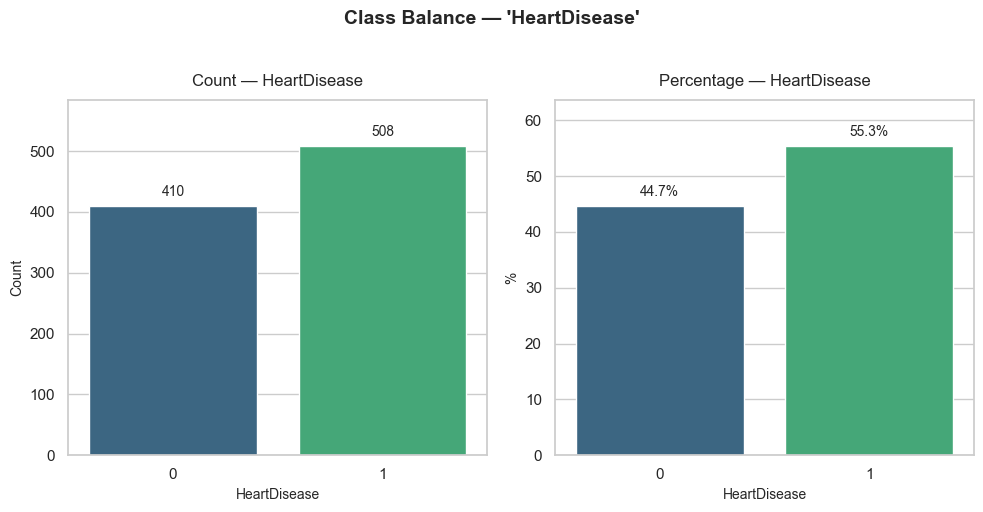

In [13]:
plot_class_balance(df, "HeartDisease")

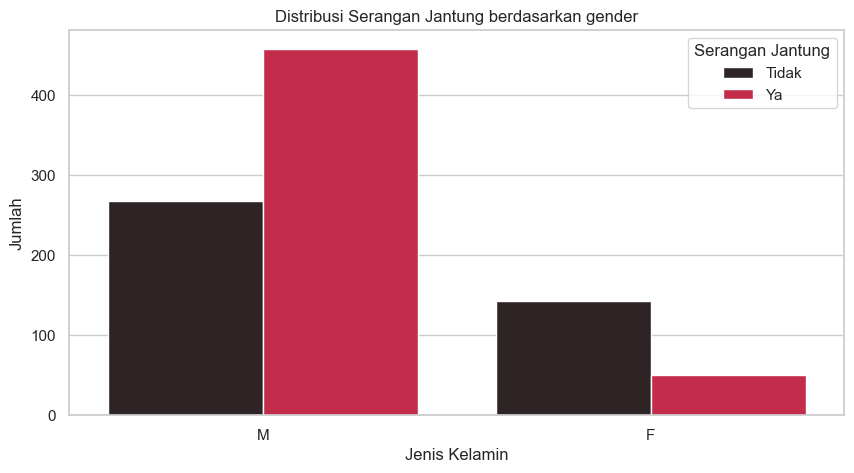

In [14]:
df['HeartDisease'] = df['HeartDisease'].map({0: 'Tidak', 1: 'Ya'})

plt.figure(figsize=(10, 5))
sns.countplot(df, x='Sex', hue='HeartDisease', palette='dark:crimson')
plt.title('Distribusi Serangan Jantung berdasarkan gender')
plt.xlabel('Jenis Kelamin')
plt.ylabel('Jumlah')
plt.legend(title='Serangan Jantung')
plt.show()

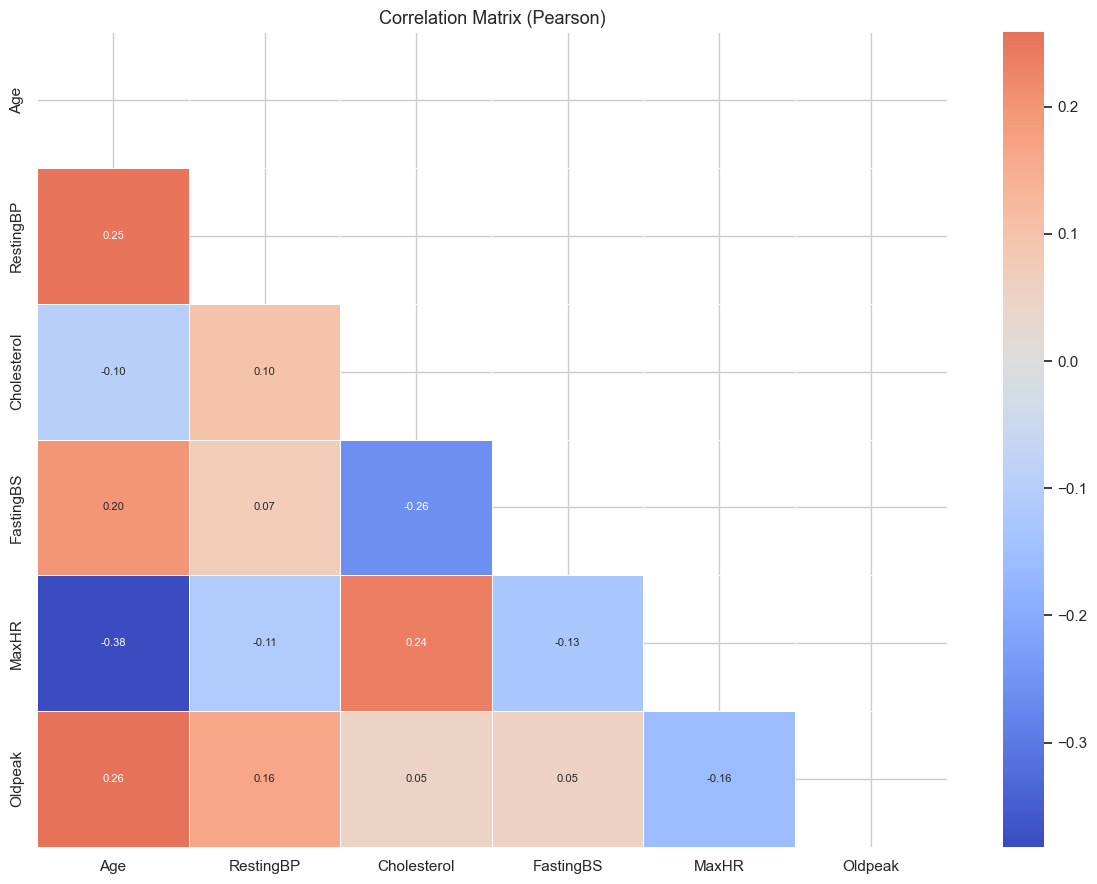

In [16]:
correlation_matrix(df)